In [1]:
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
# torch.multiprocessing.set_start_method('spawn', force=True)
import time
import importlib
import torch.optim as optim
from torchsummary import summary
import os
import statistics

os.chdir("../")
from src.data_preparation import SimulatedDataset, collate_function, load_real_data
from src.transformers import MiniTransformer
import src.transformers as transformerFunctions
from src.transformers import init_weights_recursive
from src.transformers import print_parameters
from src.transformers import create_custom_mask_pair,create_custom_mask_pred, create_distance_to_end_matrix, create_pairwise_distance_matrix
from src.evaluation import calculate_bench1_loss, calculate_bench2_loss, calculate_repeat_loss, calculate_regression_loss, evaluate_mini_transformer
from src.statistical_testing import statistical_testing, print_p_values, plot_context_predindex_pair_effect, get_context_predindex_pair_effect
import torch.autograd.profiler as profiler
from sklearn.model_selection import KFold
device = torch.device("cpu")

In [2]:

if __name__ == '__main__':
    # Hyperparameters
    # data_str = "ghq_b_sum"
    data_str = "ghq_sum"
    # data_str = "simulation"
    batch_size = 2          # Batch size for loading data
    dk = 1                  # d_k
    dv = 1                  # d_v
    nheads = 8             # number of heads
    ncum = 8                 # number of cumulants
    maxlen = 10             # maximum length of the sequence
    learning_rate = 1e-3
    lambda_l2 = 1e-3
    EPOCHS = 100
    target_sample_size = 8
    nrepp = 10

    
    # load real data
    data, maxlen = load_real_data(data_str)
    

    n = len(data)
    p = data[0].shape[1]
    print("Sample size: ", len(data), "\n")
    
    train_dataset = data
    
    predindex = 9

    # Set the random seed for reproducibility
    torch.manual_seed(1)

    mask_pairwise = create_custom_mask_pair(maxlen, device)
    mask_pred = create_custom_mask_pred(maxlen, device)
    distance_to_end_matrix = create_distance_to_end_matrix(maxlen, device)
    pairwise_distance_matrix = create_pairwise_distance_matrix(maxlen, device)


    dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_function,  num_workers=0)
    
    model = MiniTransformer(p, nheads, dk, dv, ncum, mask_pairwise,mask_pred, pairwise_distance_matrix, distance_to_end_matrix,  device)

    model.apply(init_weights_recursive)
    model.to(device)

    # model = torch.compile(model)
    # Start the timer
    start_time = time.time()

    # Define optimizer
    # optimizer = optim.Adam(model.parameters(), lr= learning_rate, weight_decay=lambda_l2)
    optimizer = optim.Adam(model.parameters(), lr= learning_rate)
    
    print("Number of Parameters", transformerFunctions.count_parameters(model))
    
    run_path = transformerFunctions.train_mini_transformer(model, dataloader, optimizer, lambda_l2, EPOCHS, device)


    # End the timer
    end_time = time.time()

    # Calculate and print the execution time
    execution_time = end_time - start_time 
    print(f"Execution time: {execution_time:.6f} seconds")




Sample size:  878 

Number of Parameters 420
EPOCH 1:
avg_loss: 16.39486
EPOCH 11:
avg_loss: 12.70991
EPOCH 21:
avg_loss: 12.30436
EPOCH 31:
avg_loss: 12.14645
EPOCH 41:
avg_loss: 12.10838
EPOCH 51:
avg_loss: 12.06477
EPOCH 61:
avg_loss: 12.05786
EPOCH 71:
avg_loss: 12.06123
EPOCH 81:
avg_loss: 12.04663
EPOCH 91:
avg_loss: 12.04397
Execution time: 42.763730 seconds


In [3]:
avepval, stdpval, context, targetall = statistical_testing(model, train_dataset, p, predindex, nrepp, target_sample_size)

Repetition 1/10
Processed 10000000 combinations out of approximately 100000000
Processed 20000000 combinations out of approximately 100000000
Processed 30000000 combinations out of approximately 100000000
Processed 40000000 combinations out of approximately 100000000
Processed 50000000 combinations out of approximately 100000000
Processed 60000000 combinations out of approximately 100000000
Processed 70000000 combinations out of approximately 100000000
Processed 80000000 combinations out of approximately 100000000
Processed 90000000 combinations out of approximately 100000000
Processed 100000000 combinations out of approximately 100000000
tensor([4.7369e-03, 3.2422e-01, 1.3460e-01, 3.0060e-05, 7.1978e-01, 1.7642e-02,
        7.2675e-01, 4.7605e-01, 2.5649e-01, 2.3600e-06], device='mps:0')
Repetition 2/10
Processed 10000000 combinations out of approximately 100000000
Processed 20000000 combinations out of approximately 100000000
Processed 30000000 combinations out of approximately 10000

In [4]:
print_p_values(avepval, stdpval)

Variable 1: 0.0605 ± 0.11
Variable 2: 0.2444 ± 0.15
Variable 3: 0.1543 ± 0.06
Variable 4: 0.0002 ± 0.00
Variable 5: 0.7278 ± 0.07
Variable 6: 0.0831 ± 0.09
Variable 7: 0.7854 ± 0.09
Variable 8: 0.3214 ± 0.13
Variable 9: 0.2760 ± 0.13
Variable 10: 0.3923 ± 0.43


In [5]:
context_predindex_pair_effect = get_context_predindex_pair_effect(model, p, context, targetall, nrepp)    

Repetition 1/10
Repetition 2/10
Repetition 3/10
Repetition 4/10
Repetition 5/10
Repetition 6/10
Repetition 7/10
Repetition 8/10
Repetition 9/10
Repetition 10/10


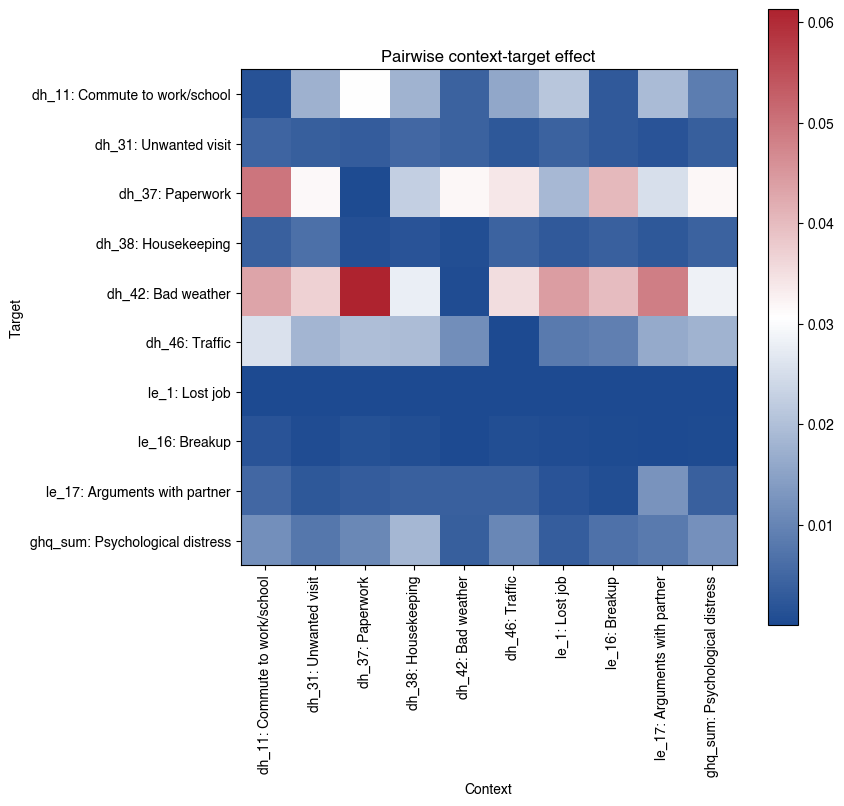

<module 'matplotlib.pyplot' from '/Users/farhadyar/Desktop/mini_transformer/env/lib/python3.10/site-packages/matplotlib/pyplot.py'>

In [6]:
plot_context_predindex_pair_effect(context_predindex_pair_effect, data_str, "./notebooks")

In [86]:
houskeeping_one_hot = torch.tensor([0,0,0,1,0,0,0,0,0,0]).float()

model((houskeeping_one_hot.unsqueeze(0).unsqueeze(0), [1.0]))

tensor([[[0.2154, 0.0471, 0.1923, 0.7728, 0.2453, 0.0494, 0.0076, 0.0091,
          0.0250, 0.1538]]], grad_fn=<AddBackward0>)

In [87]:
houskeeping_one_hot = torch.tensor([0,0,0,0,0,1,0,0,0,0]).float()

model((houskeeping_one_hot.unsqueeze(0).unsqueeze(0), [1.0]))

tensor([[[0.2042, 0.0572, 0.1436, 0.7454, 0.2051, 0.1884, 0.0097, 0.0058,
          0.0290, 0.1730]]], grad_fn=<AddBackward0>)

In [88]:
houskeeping_one_hot = torch.tensor([0,0,0,0,0,0,0,0,0,0]).float()

model((houskeeping_one_hot.unsqueeze(0).unsqueeze(0), [1.0]))

tensor([[[0.1946, 0.0483, 0.1381, 0.7479, 0.1898, 0.0508, 0.0102, 0.0043,
          0.0204, 0.1833]]], grad_fn=<AddBackward0>)

In [89]:
houskeeping_one_hot = torch.tensor([0,0,0,1,0,1,0,0,0,0]).float()

model((houskeeping_one_hot.unsqueeze(0).unsqueeze(0), [1.0]))

tensor([[[0.2250, 0.0560, 0.1978, 0.7703, 0.2605, 0.1871, 0.0072, 0.0107,
          0.0336, 0.1436]]], grad_fn=<AddBackward0>)

In [90]:
houskeeping_one_hot = torch.tensor([1,0,0,1,0,1,0,0,0,0]).float()

model((houskeeping_one_hot.unsqueeze(0).unsqueeze(0), [1.0]))

tensor([[[0.3961, 0.0631, 0.2119, 0.7799, 0.2695, 0.1994, 0.0028, 0.0060,
          0.0496, 0.1394]]], grad_fn=<AddBackward0>)

In [105]:
houskeeping_one_hot = torch.tensor([0,0,0,1,0,1,0,0,0,1]).float()

model((houskeeping_one_hot.unsqueeze(0).unsqueeze(0), [1.0]))

tensor([[[0.2238, 0.0592, 0.1986, 0.7612, 0.2687, 0.1903, 0.0128, 0.0207,
          0.0456, 0.3142]]], grad_fn=<AddBackward0>)